# Cafe Reward Program Analysis

In [1]:
#Import required libraries

import pandas as pd
import numpy as np

import scipy.stats as ss

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


## Data Cleaning, Preparation and Preprocessing

In [2]:
# Read the files
url1 = 'https://github.com/MariaSozinova/Cafe-Reward-Program-Analysis/raw/refs/heads/main/data%20files/events.csv'
url2 = 'https://github.com/MariaSozinova/Cafe-Reward-Program-Analysis/raw/refs/heads/main/data%20files/offers.csv'
url3 = 'https://github.com/MariaSozinova/Cafe-Reward-Program-Analysis/raw/refs/heads/main/data%20files/customers.csv'

In [3]:
#The dataset with program events
ev = pd.read_csv(url1)
ev.head()

,customer_id,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [4]:
#The dataset with details of the offers
offers = pd.read_csv(url2)
offers.head()

,offer_id,offer_type,difficulty,reward,duration,channels
0,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7,"['email', 'mobile', 'social']"
1,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5,"['web', 'email', 'mobile', 'social']"
2,3f207df678b143eea3cee63160fa8bed,informational,0,0,4,"['web', 'email', 'mobile']"
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7,"['web', 'email', 'mobile']"
4,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20,5,10,"['web', 'email']"


In [5]:
#The dataset with information about the customers
customers = pd.read_csv(url3)
customers.head()

,customer_id,became_member_on,gender,age,income
0,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN,118,NaN
1,0610b486422d4921ae7d2bf64640c50b,20170715,F,55,112000.0
2,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN,118,NaN
3,78afa995795e4d85b5d9ceeca43f5fef,20170509,F,75,100000.0
4,a03223e636434f42ac4c3df47e8bac43,20170804,NaN,118,NaN


In [6]:
#Start working with the first dataset 'events'. Check data types
ev.dtypes

customer_id    object
event          object
value          object
time            int64
dtype: object

In [7]:
#Column 'value' needs further preparation.
#First of all, check whether it is a real dictionary type

print(type(ev['value'].iloc[0]))

<class 'str'>


In [8]:
#The type of the column is str, convert it in order to be able to unpack the dictionary

import ast
ev['value'] = ev['value'].apply(ast.literal_eval)

In [9]:
#Check the column type again
print(type(ev['value'].iloc[0]))

<class 'dict'>


In [10]:
#Unpack values from column 'value' into a separate dataframe so that all the keys of the dictionary
#become the columns of the dataframe

df_unpacked = pd.json_normalize(ev['value'])


In [11]:
df_unpacked.tail(20)

,offer id,amount,offer_id,reward
306514,NaN,8.20,NaN,NaN
306515,NaN,2.60,NaN,NaN
306516,NaN,9.20,NaN,NaN
306517,NaN,11.70,NaN,NaN
306518,NaN,40.67,NaN,NaN
306519,NaN,31.13,NaN,NaN
306520,NaN,1.64,NaN,NaN
306521,NaN,17.35,NaN,NaN
306522,NaN,4.42,NaN,NaN
306523,NaN,18.35,NaN,NaN


In [12]:
#Since we will be merging the initial dataframe with the dateframe containing  values unpacked from the dictionary,
#we need to reset the indices in both the datasets to ensure they align
ev.reset_index(drop=True, inplace=True)
df_unpacked.reset_index(drop=True, inplace=True)

In [13]:
#Merge the dataframes 
ev_extended = pd.merge(ev, df_unpacked, left_index=True, right_index=True)
ev_extended.head(20)

,customer_id,event,value,time,offer id,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,NaN
5,389bc3fa690240e798340f5a15918d5c,offer received,{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'},0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,NaN
6,c4863c7985cf408faee930f111475da3,offer received,{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'},0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,NaN
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,{'offer id': '3f207df678b143eea3cee63160fa8bed'},0,3f207df678b143eea3cee63160fa8bed,NaN,NaN,NaN
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN
9,31dda685af34476cad5bc968bdb01c53,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN


In [14]:
#Clean the merged dataset
#Remove  column 'value' and rename the column with received offers
ev_extended_updated = ev_extended.drop(columns=['value']).rename(columns={'offer id' : 'offer_id_received'})
ev_extended_updated.head()

,customer_id,event,time,offer_id_received,amount,offer_id,reward
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,NaN


In [15]:
#Merge the above dataset with the dataset 'offers' so that for each event
#we have the info about the offer, to which such event is attributed
df_left = pd.merge(ev_extended_updated, offers, on='offer_id', how='left')
df_left.head(20)

,customer_id,event,time,offer_id_received,amount,offer_id,reward_x,offer_type,difficulty,reward_y,duration,channels
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,389bc3fa690240e798340f5a15918d5c,offer received,0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,c4863c7985cf408faee930f111475da3,offer received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,3f207df678b143eea3cee63160fa8bed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,31dda685af34476cad5bc968bdb01c53,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
#Check NaN values
df_left.isna().sum()

customer_id               0
event                     0
time                      0
offer_id_received    172532
amount               167581
offer_id             272955
reward_x             272955
offer_type           272955
difficulty           272955
reward_y             272955
duration             272955
channels             272955
dtype: int64

In [17]:
#Total amount of transactions
df_left['amount'].sum()

1775451.9700000004

In [18]:
#Total amount of rewards
df_left['reward_x'].sum()

164676.0

In [19]:
#Further cleaning of the dataset: remove excessive columns and rename columns where appropriate
df_left1 = df_left.drop(columns=['reward_y'])\
            .rename(columns={'offer_id' : 'offer_id_completed'})

In [20]:
df_left1 = df_left1.rename(columns={'offer_id_received' : 'offer_id'})

In [21]:
#It is required that the info on offer type is to be not only against completed ofers, 
#but against received offers as well. Another merge is required;
#this will allow to fill in NaN values with informaiton from 'offers' dataset
df_left_final = pd.merge(df_left1, offers, on='offer_id', how='left')
df_left_final


,customer_id,event,time,offer_id,amount,offer_id_completed,reward_x,offer_type_x,difficulty_x,duration_x,channels_x,offer_type_y,difficulty_y,reward,duration_y,channels_y
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']"
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,discount,20.0,5.0,10.0,"['web', 'email']"
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,discount,10.0,2.0,7.0,"['web', 'email', 'mobile']"
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,discount,10.0,2.0,10.0,"['web', 'email', 'mobile', 'social']"
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,NaN,1.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,NaN,9.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306531,a00058cf10334a308c68e7631c529907,transaction,714,NaN,3.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,NaN,3.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_left_final.isna().sum()

customer_id                0
event                      0
time                       0
offer_id              172532
amount                167581
offer_id_completed    272955
reward_x              272955
offer_type_x          272955
difficulty_x          272955
duration_x            272955
channels_x            272955
offer_type_y          172532
difficulty_y          172532
reward                172532
duration_y            172532
channels_y            172532
dtype: int64

In [23]:
#Filling in NaN values
df_left_final['offer_type_x'] = df_left_final['offer_type_x'].fillna(df_left_final['offer_type_y'])

In [24]:
df_left_final['reward_x'] = df_left_final['reward'].fillna(df_left_final['reward_x'])

In [25]:
df_left_final['difficulty_x'] = df_left_final['difficulty_x'].fillna(df_left_final['difficulty_y'])

In [26]:
df_left_final['duration_x'] = df_left_final['duration_x'].fillna(df_left_final['duration_y'])

In [27]:
df_left_final['channels_x'] = df_left_final['channels_x'].fillna(df_left_final['channels_y'])

In [28]:
df_left_final.tail(20)

,customer_id,event,time,offer_id,amount,offer_id_completed,reward_x,offer_type_x,difficulty_x,duration_x,channels_x,offer_type_y,difficulty_y,reward,duration_y,channels_y
306514,f1e4fd36e5a0446f83861308bddf6945,transaction,714,NaN,8.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306515,0b64be3b241c4407a5c9a71781173829,transaction,714,NaN,2.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306516,86d03d35d7e0434b935e7743e83be3a0,transaction,714,NaN,9.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306517,3408fd05c781401f8442fb6dbaaea9c7,transaction,714,NaN,11.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306518,1593d617fac246ef8e50dbb0ffd77f5f,transaction,714,NaN,40.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306519,f1b31d07b5d84f69a2d5f1d07843989e,transaction,714,NaN,31.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306520,2ce987015ec0404a97ba333e8e814090,transaction,714,NaN,1.64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306521,2e33545f0a764d27b2ccff95fc8d72c4,transaction,714,NaN,17.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306522,d1c4500ace2e45e9a45d3cd2fccac8d8,transaction,714,NaN,4.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
306523,b65affd9e07346a1906364a396950e3d,transaction,714,NaN,18.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
#Remove excessive columns
events_with_offers_info = df_left_final.drop(columns=['reward', 'offer_type_y', 'difficulty_y', 'duration_y', 'channels_y'])
events_with_offers_info.head(20)

,customer_id,event,time,offer_id,amount,offer_id_completed,reward_x,offer_type_x,difficulty_x,duration_x,channels_x
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,5.0,bogo,5.0,7.0,"['web', 'email', 'mobile']"
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']"
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,2.0,discount,10.0,7.0,"['web', 'email', 'mobile']"
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,2.0,discount,10.0,10.0,"['web', 'email', 'mobile', 'social']"
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,10.0,bogo,10.0,5.0,"['web', 'email', 'mobile', 'social']"
5,389bc3fa690240e798340f5a15918d5c,offer received,0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,5.0,bogo,5.0,5.0,"['web', 'email', 'mobile', 'social']"
6,c4863c7985cf408faee930f111475da3,offer received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,3.0,discount,7.0,7.0,"['web', 'email', 'mobile', 'social']"
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,3f207df678b143eea3cee63160fa8bed,NaN,NaN,0.0,informational,0.0,4.0,"['web', 'email', 'mobile']"
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']"
9,31dda685af34476cad5bc968bdb01c53,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']"


In [30]:
#Rename required columns
events_with_offers_info = events_with_offers_info.rename(columns={'reward_x':'reward', 'offer_type_x':'offer_type','difficulty_x':'difficulty', 'channels_x':'channels', 'duration_x':'duration'  })

In [31]:
events_with_offers_info.tail(20)

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels
306514,f1e4fd36e5a0446f83861308bddf6945,transaction,714,NaN,8.20,NaN,NaN,NaN,NaN,NaN,NaN
306515,0b64be3b241c4407a5c9a71781173829,transaction,714,NaN,2.60,NaN,NaN,NaN,NaN,NaN,NaN
306516,86d03d35d7e0434b935e7743e83be3a0,transaction,714,NaN,9.20,NaN,NaN,NaN,NaN,NaN,NaN
306517,3408fd05c781401f8442fb6dbaaea9c7,transaction,714,NaN,11.70,NaN,NaN,NaN,NaN,NaN,NaN
306518,1593d617fac246ef8e50dbb0ffd77f5f,transaction,714,NaN,40.67,NaN,NaN,NaN,NaN,NaN,NaN
306519,f1b31d07b5d84f69a2d5f1d07843989e,transaction,714,NaN,31.13,NaN,NaN,NaN,NaN,NaN,NaN
306520,2ce987015ec0404a97ba333e8e814090,transaction,714,NaN,1.64,NaN,NaN,NaN,NaN,NaN,NaN
306521,2e33545f0a764d27b2ccff95fc8d72c4,transaction,714,NaN,17.35,NaN,NaN,NaN,NaN,NaN,NaN
306522,d1c4500ace2e45e9a45d3cd2fccac8d8,transaction,714,NaN,4.42,NaN,NaN,NaN,NaN,NaN,NaN
306523,b65affd9e07346a1906364a396950e3d,transaction,714,NaN,18.35,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
#Add informaiton about the clients into the above dataset, for this will merge it with 'customers' dataset 

df_final = pd.merge(events_with_offers_info, customers, on='customer_id', how='left')
df_final.head(20)

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,5.0,bogo,5.0,7.0,"['web', 'email', 'mobile']",20170509,F,75,100000.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']",20170804,NaN,118,NaN
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,2.0,discount,10.0,7.0,"['web', 'email', 'mobile']",20180426,M,68,70000.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,2.0,discount,10.0,10.0,"['web', 'email', 'mobile', 'social']",20170925,NaN,118,NaN
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,10.0,bogo,10.0,5.0,"['web', 'email', 'mobile', 'social']",20171002,NaN,118,NaN
5,389bc3fa690240e798340f5a15918d5c,offer received,0,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,5.0,bogo,5.0,5.0,"['web', 'email', 'mobile', 'social']",20180209,M,65,53000.0
6,c4863c7985cf408faee930f111475da3,offer received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,3.0,discount,7.0,7.0,"['web', 'email', 'mobile', 'social']",20170824,NaN,118,NaN
7,2eeac8d8feae4a8cad5a6af0499a211d,offer received,0,3f207df678b143eea3cee63160fa8bed,NaN,NaN,0.0,informational,0.0,4.0,"['web', 'email', 'mobile']",20171111,M,58,51000.0
8,aa4862eba776480b8bb9c68455b8c2e1,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']",20170911,F,61,57000.0
9,31dda685af34476cad5bc968bdb01c53,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"['web', 'email']",20160211,F,62,71000.0


In [33]:
df_final.shape

(306534, 15)

In [34]:
#check type of data
df_final.dtypes

customer_id            object
event                  object
time                    int64
offer_id               object
amount                float64
offer_id_completed     object
reward                float64
offer_type             object
difficulty            float64
duration              float64
channels               object
became_member_on        int64
gender                 object
age                     int64
income                float64
dtype: object

In [35]:
#Convert the column 'became_member_on' into datetime
df_final['became_member_on'] = pd.to_datetime(df_final['became_member_on'].astype(str), format='%Y%m%d')

In [36]:
df_final.dtypes

customer_id                   object
event                         object
time                           int64
offer_id                      object
amount                       float64
offer_id_completed            object
reward                       float64
offer_type                    object
difficulty                   float64
duration                     float64
channels                      object
became_member_on      datetime64[ns]
gender                        object
age                            int64
income                       float64
dtype: object

In [37]:
#Check NaN values
df_final.isna().sum()

customer_id                0
event                      0
time                       0
offer_id              172532
amount                167581
offer_id_completed    272955
reward                138953
offer_type            138953
difficulty            138953
duration              138953
channels              138953
became_member_on           0
gender                 33772
age                        0
income                 33772
dtype: int64

In [38]:
#How many reward offers are there
df_final['offer_id'].nunique()

10

In [39]:
# To have the dataset in its final way I need a column which include full description of the promotion offer,
# i.e. type, difficulty, reward, duration and channels.

# To achive this we need to first process the columns with channels.
#Check the type of the column 'channels'

print(type(df_final['channels'].iloc[0]))

<class 'str'>


In [40]:
#The column 'channels' is of class 'str' and for futher actions it has to be converted into a list

def convert_to_list(channel_str):
    try:
        #if it's a valie list string, convert it using ast.literal_eval
        channels = ast.literal_eval(channel_str)
        if isinstance(channels, list):
            return channels
        else:
            return ['Unknown channels'] #Return a default list if it's not a list
    except (ValueError, SyntaxError):
        return ['Unknown channels'] #Return a default list if conversion fails

#Apply conversion function to the required column
df_final['channels'] = df_final['channels'].apply(lambda x: convert_to_list(x) if pd.notna(x) else ['Unknown channels'])
    
    

In [41]:
#Double-check the type of the column 'channels'

print(type(df_final['channels'].iloc[0]))

<class 'list'>


In [42]:
#Introduce function that will create columns with full description of the offer

def create_offer_description(row):
    
    #handle NaN values in offer_type
    offer_type = row['offer_type'] if pd.notna(row['offer_type']) else 'Unknown type'
    
    #handle NaN values in duration
    offer_duration = row['duration'] if pd.notna(row['duration']) else 'Unknown duration'
    
    #handle NaN values in difficulty
    difficulty = row['difficulty'] if pd.notna(row['difficulty']) else 'Unknown difficulty'
    
    #handle NaN values in reward
    reward = row['reward'] if pd.notna(row['reward']) else 'Unknown reward'
    
    #we have a safety list in channels, so no additional check is required
    channels = ', '.join(row['channels']) #join list into a string
    
    
    
    #Create the description
    return f"Type: {offer_type}, Difficulty: {difficulty}, Reward: {reward}, Duration: {offer_duration} days, Channels: {channels}"
    
#Apply function to each row in the dataset
df_final['offer_description'] = df_final.apply(create_offer_description, axis=1)

In [43]:
df_final.head()

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,5.0,bogo,5.0,7.0,"[web, email, mobile]",2017-05-09,F,75,100000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"[web, email]",2017-08-04,NaN,118,NaN,"Type: discount, Difficulty: 20.0, Reward: 5.0,..."
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,2.0,discount,10.0,7.0,"[web, email, mobile]",2018-04-26,M,68,70000.0,"Type: discount, Difficulty: 10.0, Reward: 2.0,..."
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,2.0,discount,10.0,10.0,"[web, email, mobile, social]",2017-09-25,NaN,118,NaN,"Type: discount, Difficulty: 10.0, Reward: 2.0,..."
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,10.0,bogo,10.0,5.0,"[web, email, mobile, social]",2017-10-02,NaN,118,NaN,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du..."


In [44]:
#Check the list of all the offers available in the promotional campaign

df_final['offer_description'].unique()

array(['Type: bogo, Difficulty: 5.0, Reward: 5.0, Duration: 7.0 days, Channels: web, email, mobile',
       'Type: discount, Difficulty: 20.0, Reward: 5.0, Duration: 10.0 days, Channels: web, email',
       'Type: discount, Difficulty: 10.0, Reward: 2.0, Duration: 7.0 days, Channels: web, email, mobile',
       'Type: discount, Difficulty: 10.0, Reward: 2.0, Duration: 10.0 days, Channels: web, email, mobile, social',
       'Type: bogo, Difficulty: 10.0, Reward: 10.0, Duration: 5.0 days, Channels: web, email, mobile, social',
       'Type: bogo, Difficulty: 5.0, Reward: 5.0, Duration: 5.0 days, Channels: web, email, mobile, social',
       'Type: discount, Difficulty: 7.0, Reward: 3.0, Duration: 7.0 days, Channels: web, email, mobile, social',
       'Type: informational, Difficulty: 0.0, Reward: 0.0, Duration: 4.0 days, Channels: web, email, mobile',
       'Type: bogo, Difficulty: 10.0, Reward: 10.0, Duration: 7.0 days, Channels: email, mobile, social',
       'Type: informational, D

In [45]:
#Number of offers available
df_final['offer_description'].nunique()

11

In [46]:
#How many offers in total were received by the customers
df_final.query('event=="offer received"').shape[0]

76277

In [47]:
#How many offers were completed
df_final.query('event=="offer completed"').shape[0]

33579

In [48]:
#Number of offers received by type of the offer
df_final.query('event=="offer received"')\
        .groupby('offer_description', as_index=False)\
        .agg({'customer_id':'count'})\
        .rename(columns={'customer_id' : 'no_offers_received'})

,offer_description,no_offers_received
0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",7593
1,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",7658
2,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",7571
3,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",7677
4,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",7597
5,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",7632
6,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",7668
7,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",7646
8,"Type: informational, Difficulty: 0.0, Reward: ...",7618
9,"Type: informational, Difficulty: 0.0, Reward: ...",7617


In [49]:
#Number of offers completed  by type of the offer
df_final.query('event=="offer completed"')\
        .groupby('offer_description', as_index=False)\
        .agg({'customer_id':'count'})\
        .rename(columns={'customer_id' : 'no_offers_completed'})

,offer_description,no_offers_completed
0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3331
1,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3688
2,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4296
3,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4354
4,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",5317
5,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",4017
6,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",3420
7,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",5156


## Customers

In [50]:
#Number of unique customers
df_final['customer_id'].nunique()

17000

In [51]:
#What is the earliest date of becoming a customer
df_final['became_member_on'].min()

Timestamp('2013-07-29 00:00:00')

In [52]:
#What is the latest date of becoming a customer
last_date_becoming_member = df_final['became_member_on'].max()
last_date_becoming_member

Timestamp('2018-07-26 00:00:00')

In [53]:
#Select rows where the date of becoming a member is equal to the latest date of becoming a member

df_latest_membership_date = df_final[df_final['became_member_on'] == last_date_becoming_member]
df_latest_membership_date

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description
327,b65eaba56d124588aed15c484db427a8,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,10.0,bogo,10.0,5.0,"[web, email, mobile, social]",2018-07-26,M,63,78000.0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du..."
504,70f115dc7bf84a2ca3b1481639590f2b,offer received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,3.0,discount,7.0,7.0,"[web, email, mobile, social]",2018-07-26,M,47,53000.0,"Type: discount, Difficulty: 7.0, Reward: 3.0, ..."
1127,267e47de94fd46b1afa96dea1c9d3cbf,offer received,0,2298d6c36e964ae4a3e7e9706d1fb8c2,NaN,NaN,3.0,discount,7.0,7.0,"[web, email, mobile, social]",2018-07-26,M,28,33000.0,"Type: discount, Difficulty: 7.0, Reward: 3.0, ..."
1995,4be45187b24d479fbccaf1f6293ebff8,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,2.0,discount,10.0,10.0,"[web, email, mobile, social]",2018-07-26,M,43,54000.0,"Type: discount, Difficulty: 10.0, Reward: 2.0,..."
5891,039e0c539c2f4fc582423412a8bceb40,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"[web, email]",2018-07-26,M,82,32000.0,"Type: discount, Difficulty: 20.0, Reward: 5.0,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
302575,039e0c539c2f4fc582423412a8bceb40,transaction,696,NaN,1.70,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-07-26,M,82,32000.0,"Type: Unknown type, Difficulty: Unknown diffic..."
304076,f1f01be4e2344bf08b7f488c115ad374,transaction,702,NaN,11.56,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-07-26,M,85,45000.0,"Type: Unknown type, Difficulty: Unknown diffic..."
304099,42f00b6b150e45149c50db9bd642bca6,transaction,702,NaN,20.57,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-07-26,F,45,70000.0,"Type: Unknown type, Difficulty: Unknown diffic..."
305114,3b9ec536e4224688950913b9cf53362c,transaction,708,NaN,29.64,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-07-26,F,59,88000.0,"Type: Unknown type, Difficulty: Unknown diffic..."


In [54]:
#How many customers became memebrs on such date
df_latest_membership_date['customer_id'].nunique()

22

In [55]:
latest_customers_completing_orders = df_latest_membership_date[df_latest_membership_date['offer_id_completed']\
                                    .notna()]

latest_customers_completing_orders

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description
23796,baefe3a7a1f74e91b9b1963ccc011ad6,offer completed,24,NaN,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,bogo,5.0,5.0,"[web, email, mobile, social]",2018-07-26,F,78,55000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."
39207,f1f01be4e2344bf08b7f488c115ad374,offer completed,84,NaN,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,bogo,5.0,5.0,"[web, email, mobile, social]",2018-07-26,M,85,45000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."
47291,f69e66bb9d2e41eaa2aacbaa18632c08,offer completed,126,NaN,NaN,ae264e3637204a6fb9bb56bc8210ddfd,10.0,bogo,10.0,7.0,"[email, mobile, social]",2018-07-26,F,55,65000.0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du..."
78550,e4989ca3d8974e28a3fe87aa0b0ce327,offer completed,192,NaN,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,5.0,discount,20.0,10.0,"[web, email]",2018-07-26,M,46,74000.0,"Type: discount, Difficulty: 20.0, Reward: 5.0,..."
81437,b65eaba56d124588aed15c484db427a8,offer completed,204,NaN,NaN,ae264e3637204a6fb9bb56bc8210ddfd,10.0,bogo,10.0,7.0,"[email, mobile, social]",2018-07-26,M,63,78000.0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du..."
87592,6597e5ab63754726b83ba2032f008d26,offer completed,222,NaN,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,bogo,5.0,5.0,"[web, email, mobile, social]",2018-07-26,M,76,92000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."
93281,f1f01be4e2344bf08b7f488c115ad374,offer completed,240,NaN,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,discount,7.0,7.0,"[web, email, mobile, social]",2018-07-26,M,85,45000.0,"Type: discount, Difficulty: 7.0, Reward: 3.0, ..."
101366,e9b06d3e0b0e4aa1bf5da8d9e11dcde0,offer completed,276,NaN,NaN,f19421c1d4aa40978ebb69ca19b0e20d,5.0,bogo,5.0,5.0,"[web, email, mobile, social]",2018-07-26,F,77,74000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."
131766,e4989ca3d8974e28a3fe87aa0b0ce327,offer completed,348,NaN,NaN,0b1e1539f2cc45b7b9fa7c272da2e1d7,5.0,discount,20.0,10.0,"[web, email]",2018-07-26,M,46,74000.0,"Type: discount, Difficulty: 20.0, Reward: 5.0,..."
132585,e9b06d3e0b0e4aa1bf5da8d9e11dcde0,offer completed,348,NaN,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0,bogo,5.0,7.0,"[web, email, mobile]",2018-07-26,F,77,74000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura..."


In [56]:
latest_customers_completing_orders['customer_id'].nunique()

13

In [57]:
# Add column for completed orders
df_final['completed'] = df_final['offer_id_completed'].notna().astype(int)

In [58]:
df_final.tail()

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description,completed
306529,b3a1272bc9904337b331bf348c3e8c17,transaction,714,NaN,1.59,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-01-01,M,66,47000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
306530,68213b08d99a4ae1b0dcb72aebd9aa35,transaction,714,NaN,9.53,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2018-04-08,M,52,62000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
306531,a00058cf10334a308c68e7631c529907,transaction,714,NaN,3.61,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2013-09-22,F,63,52000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
306532,76ddbd6576844afe811f1a3c0fbb5bec,transaction,714,NaN,3.53,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2016-07-09,M,57,40000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
306533,c02b10e8752c4d8e9b73f918558531f7,transaction,714,NaN,4.05,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2015-12-11,NaN,118,NaN,"Type: Unknown type, Difficulty: Unknown diffic...",0


In [59]:
#Check completion of orders by gender
contingency_table = pd.crosstab(df_final['gender'], df_final['completed'])
contingency_table

completed,0,1
gender,,
F,97624,15477
M,139224,16466
O,3470,501


In [60]:
#Filter  rows (events) where transactions took place
transactions = df_final[df_final['amount'].notna()]

In [61]:
#For each customer, calculate the number of completed offers
completion_by_customer = transactions.groupby('customer_id').agg({'event':'count'}).reset_index().rename(columns={'event':'no_offers_completed'})
completion_by_customer

,customer_id,no_offers_completed
0,0009655768c64bdeb2e877511632db8f,8
1,00116118485d4dfda04fdbaba9a87b5c,3
2,0011e0d4e6b944f998e987f904e8c1e5,5
3,0020c2b971eb4e9188eac86d93036a77,8
4,0020ccbbb6d84e358d3414a3ff76cffd,12
...,...,...
16573,fff3ba4757bd42088c044ca26d73817a,11
16574,fff7576017104bcc8677a8d63322b5e1,6
16575,fff8957ea8b240a6b5e634b6ee8eafcf,5
16576,fffad4f4828548d1b5583907f2e9906b,12


In [62]:
#Create dataframe with information on each customer and no of offers completed by each customer
customers_analysis = pd.merge(completion_by_customer, customers, on='customer_id')

In [63]:
customers_analysis.head()

,customer_id,no_offers_completed,became_member_on,gender,age,income
0,0009655768c64bdeb2e877511632db8f,8,20170421,M,33,72000.0
1,00116118485d4dfda04fdbaba9a87b5c,3,20180425,NaN,118,NaN
2,0011e0d4e6b944f998e987f904e8c1e5,5,20180109,O,40,57000.0
3,0020c2b971eb4e9188eac86d93036a77,8,20160304,F,59,90000.0
4,0020ccbbb6d84e358d3414a3ff76cffd,12,20161111,F,24,60000.0


In [64]:
#Check NaN values
customers_analysis.isna().sum()

customer_id               0
no_offers_completed       0
became_member_on          0
gender                 2086
age                       0
income                 2086
dtype: int64

In [65]:
#Deselect those customers where gender is not indicated
customers_analysis_1 = customers_analysis.dropna()

In [66]:
customers_analysis_1.head()

,customer_id,no_offers_completed,became_member_on,gender,age,income
0,0009655768c64bdeb2e877511632db8f,8,20170421,M,33,72000.0
2,0011e0d4e6b944f998e987f904e8c1e5,5,20180109,O,40,57000.0
3,0020c2b971eb4e9188eac86d93036a77,8,20160304,F,59,90000.0
4,0020ccbbb6d84e358d3414a3ff76cffd,12,20161111,F,24,60000.0
5,003d66b6608740288d6cc97a6903f4f0,18,20170621,F,26,73000.0


### Correlation between comleted offers and gender. Analysis of customers by age group. Correlation between completed offers and age

In [67]:
# Determine mean of numbers of offerscompleted gender-wise
gender_correlation = customers_analysis_1.groupby('gender')['no_offers_completed'].mean()
gender_correlation

gender
F    8.239947
M    8.775648
O    8.730392
Name: no_offers_completed, dtype: float64

In [68]:
#Introduce colors for sns palette which will align with the future dashboard
my_colors = ["#627281", "#b29f91",  
             "#562b1a"] 

In [69]:
sns.set_palette( my_colors ) 

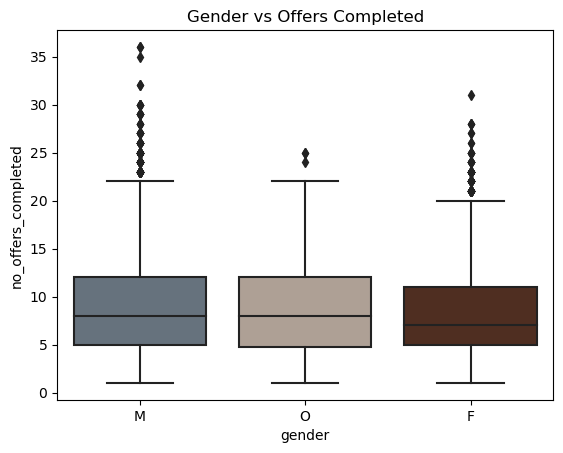

In [70]:
# Construct a box plot to visualize Gender vs Offers Completed
sns.boxplot(x='gender', y='no_offers_completed', data=customers_analysis_1)
plt.title('Gender vs Offers Completed')
plt.show()

(array([1302., 1426., 1995., 3292., 3177., 1980.,  943.,  350.,   27.,
        2086.]),
 array([ 18.,  28.,  38.,  48.,  58.,  68.,  78.,  88.,  98., 108., 118.]),
 <BarContainer object of 10 artists>)

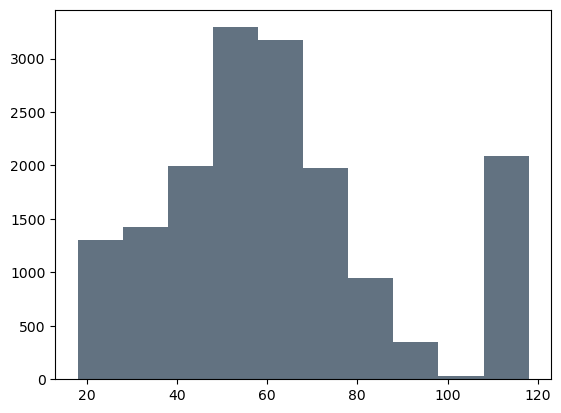

In [71]:
#Check the distribution of age in data
plt.hist(customers_analysis['age'])

In [72]:
#There are customers with age over 100. Further check is required for this group of the customers
customers_analysis.groupby('age').agg({'customer_id':'count'})

,customer_id
age,
18,69
19,135
20,133
21,140
22,130
...,...
98,5
99,5
100,12


In [73]:
customers_analysis.query('age==118')

,customer_id,no_offers_completed,became_member_on,gender,age,income
1,00116118485d4dfda04fdbaba9a87b5c,3,20180425,NaN,118,NaN
11,0063def0f9c14bc4805322a488839b32,3,20180615,NaN,118,NaN
12,0069a50874d846438e58acff5e594725,5,20160503,NaN,118,NaN
19,0092a132ead946ceb30d11a1ed513d20,3,20180502,NaN,118,NaN
21,009d10c2c38a4fd795a7bc6ddbbddb78,7,20180627,NaN,118,NaN
...,...,...,...,...,...,...
16540,ff71a5ae9c964d4195f69d15cd2aceeb,8,20170928,NaN,118,NaN
16541,ff726a9e9f8643ee9ae1c7b074a583dc,2,20171125,NaN,118,NaN
16552,ff964fce42a74d519bd1ad2e0e20cd9e,15,20161203,NaN,118,NaN
16569,ffecb1f8543f4bf7bade023de366d6bf,3,20171027,NaN,118,NaN


In [74]:
#Check other aged customers 
customers_analysis.query('age==101')

,customer_id,no_offers_completed,became_member_on,gender,age,income
278,047ad0135cfe4c0ea5ba019da4de9c52,10,20170309,F,101,59000.0
1376,1593d617fac246ef8e50dbb0ffd77f5f,9,20171127,F,101,82000.0
5008,4d2ccfcbbebf4bd9baf4b7e433d0e288,15,20171004,F,101,43000.0
13721,d2fdc2be8ab64e4ba04830d441e53fd5,8,20150526,F,101,99000.0
14603,e0ea90ddd2f147e082d21e97f51ec1b1,5,20171109,F,101,56000.0


In [75]:
customers_analysis.query('age==100')

,customer_id,no_offers_completed,became_member_on,gender,age,income
2292,24c1287eb7a84cfd80472a82e05b1d57,14,20150828,F,100,63000.0
2542,28bbebb2b76f4057b1115dd80441e37a,7,20170905,F,100,118000.0
3831,3b34370727654cfca5322bca2aba9ffd,4,20180330,F,100,96000.0
8672,857fc6e18cf74f7b8ebce26bbfbd3028,9,20180123,F,100,109000.0
8699,85f4e5ea5c0044619482bfe16ae32c01,3,20171231,F,100,71000.0
9885,97d7120a2a154a6d98b053e64b782ecf,12,20151013,M,100,63000.0
10040,9a30ad4712a341e5be025cf0f96d7ee3,9,20171019,F,100,42000.0
10143,9b675a966bd040eeac75f9aa01b14773,2,20180410,F,100,70000.0
10367,9eb812054d564bdba180dc365f186e23,11,20160629,O,100,83000.0
11588,b12e8e0f14ae4ad0b576f7c016e7e89b,12,20150911,M,100,98000.0


In [76]:
#It looks like customers of 118, are customers with unknown age and other parameters like 
#gender and income, for more accurate result of correlation between completed orders and age we will drop 
#this values

In [77]:
customers_analysis_for_corr = customers_analysis.query('age<118')

In [78]:
correlation_age = customers_analysis_for_corr['no_offers_completed'].corr(customers_analysis_for_corr['age'])
correlation_income = customers_analysis_for_corr['no_offers_completed'].corr(customers_analysis_for_corr['income'])

print(f"Correlation between offers completed and age: {correlation_age}")
print(f"Correlation between offers completed and income: {correlation_income}")

Correlation between offers completed and age: -0.15368825632359523
Correlation between offers completed and income: -0.26294418441285833


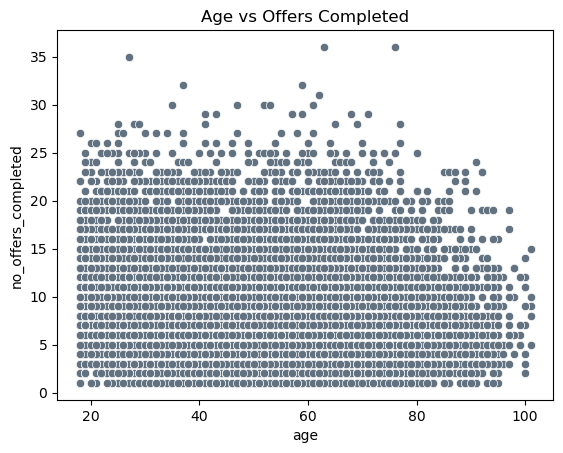

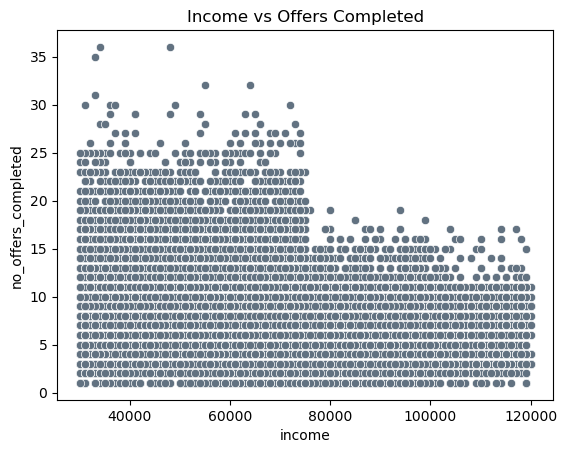

In [79]:
# Scatter plot for Age vs Offers Completed
sns.scatterplot(x='age', y='no_offers_completed', data=customers_analysis_for_corr)
plt.title('Age vs Offers Completed')
plt.show()

# Scatter plot for Income vs Offers Completed
sns.scatterplot(x='income', y='no_offers_completed', data=customers_analysis_for_corr)
plt.title('Income vs Offers Completed')
plt.show()

In [80]:
#No strong correlation between gender, age or income vs completed offers was observed

## RFM Analysis

In [81]:
#For RFM Analysis we will need only events with the transactions.

transactions.head()



,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description,completed
12654,02c083884c7d45b39cc68e1314fec56c,transaction,0,NaN,0.83,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2016-07-11,F,20,30000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,transaction,0,NaN,34.56,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2016-01-17,M,42,96000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
12659,54890f68699049c2a04d415abc25e717,transaction,0,NaN,13.23,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2017-12-28,M,36,56000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
12670,b2f1cd155b864803ad8334cdf13c4bd2,transaction,0,NaN,19.51,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2017-10-16,F,55,94000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0
12671,fe97aa22dd3e48c8b143116a8403dd52,transaction,0,NaN,18.97,NaN,NaN,NaN,NaN,NaN,[Unknown channels],2017-12-17,F,39,67000.0,"Type: Unknown type, Difficulty: Unknown diffic...",0


In [82]:
# Delete columns which will not require for RFM analysis
transactions_for_rfm = transactions.drop(columns=['event', 'offer_id', 'offer_id_completed', 'reward', 'offer_type', 'difficulty', 'duration', 'channels', 'completed', 'offer_description'])

In [83]:
transactions_for_rfm.head()

,customer_id,time,amount,became_member_on,gender,age,income
12654,02c083884c7d45b39cc68e1314fec56c,0,0.83,2016-07-11,F,20,30000.0
12657,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,34.56,2016-01-17,M,42,96000.0
12659,54890f68699049c2a04d415abc25e717,0,13.23,2017-12-28,M,36,56000.0
12670,b2f1cd155b864803ad8334cdf13c4bd2,0,19.51,2017-10-16,F,55,94000.0
12671,fe97aa22dd3e48c8b143116a8403dd52,0,18.97,2017-12-17,F,39,67000.0


In [84]:
transactions_for_rfm.to_csv('/Users/danil/Documents/articles/RFM analysis/transactions_for_rfm.csv')

In [85]:
#First, we identify the latest date or, in our case, the latest time in the dataset
latest_time = transactions_for_rfm['time'].max()
latest_time

714

In [87]:
# Create the table with Recency, Frequency and Monetary Values for each customer
rfmTable = transactions_for_rfm.groupby('customer_id').agg({'time': lambda x: round((latest_time - x.max()) / 24), # Recency 
                                        'customer_id': lambda x: len(x),      # Frequency 
                                        'amount': lambda x: x.sum()}) # Monetary Value 

In [88]:
rfmTable['time'] = rfmTable['time'].astype(int)
rfmTable.rename(columns={'time': 'recency', 
                         'customer_id': 'frequency', 
                         'amount': 'monetary_value'}, inplace=True)

In [89]:
rfmTable.head()

,recency,frequency,monetary_value
customer_id,,,
0009655768c64bdeb2e877511632db8f,1,8,127.60
00116118485d4dfda04fdbaba9a87b5c,10,3,4.09
0011e0d4e6b944f998e987f904e8c1e5,2,5,79.46
0020c2b971eb4e9188eac86d93036a77,0,8,196.86
0020ccbbb6d84e358d3414a3ff76cffd,2,12,154.05


In [90]:
rfmTable.shape

(16578, 3)

In [91]:
#Double-check number of unique customer in the transactions dataset
transactions_for_rfm.customer_id.nunique()

16578

In [92]:
#  Create four groups for each parameter(recency, frequency and monetary value) using quantiles
quantiles = rfmTable.quantile(q=[0.25,0.5,0.75])
quantiles

,recency,frequency,monetary_value
0.25,1.0,5.0,23.6825
0.50,2.0,7.0,72.4100
0.75,5.0,11.0,150.9375


In [94]:
rfmSegmentation = rfmTable

In [95]:
# Create function which will distribute the customers into classes (from 1 to 4) in all the parameters
# (Recency, Frequency and Monetary Value). 
# Class '111' will the best one with higher monetary values and frequency and less recency, 
# class '444' will include users on the point of leaving the app (low frequency and monetary value and large recency)

def RClass(value,parameter_name,quantiles_table):
    if value <= quantiles_table[parameter_name][0.25]:
        return 1
    elif value <= quantiles_table[parameter_name][0.50]:
        return 2
    elif value <= quantiles_table[parameter_name][0.75]: 
        return 3
    else:
        return 4


def FMClass(value, parameter_name,quantiles_table):
    if value <= quantiles_table[parameter_name][0.25]:
        return 4
    elif value <= quantiles_table[parameter_name][0.50]:
        return 3
    elif value <= quantiles_table[parameter_name][0.75]: 
        return 2
    else:
        return 1

In [96]:
# Apply function to the rfmSegmentation table
rfmSegmentation['R_Quartile'] = rfmSegmentation['recency'].apply(RClass, args=('recency',quantiles))

rfmSegmentation['F_Quartile'] = rfmSegmentation['frequency'].apply(FMClass, args=('frequency',quantiles))

rfmSegmentation['M_Quartile'] = rfmSegmentation['monetary_value'].apply(FMClass, args=('monetary_value',quantiles))

rfmSegmentation['RFMClass'] = rfmSegmentation.R_Quartile\
                            .map(str) + rfmSegmentation.F_Quartile\
                            .map(str) + rfmSegmentation.M_Quartile\
                            .map(str)

In [97]:
rfmSegmentation.head() 

,recency,frequency,monetary_value,R_Quartile,F_Quartile,M_Quartile,RFMClass
customer_id,,,,,,,
0009655768c64bdeb2e877511632db8f,1,8,127.60,1,2,2,122
00116118485d4dfda04fdbaba9a87b5c,10,3,4.09,4,4,4,444
0011e0d4e6b944f998e987f904e8c1e5,2,5,79.46,2,4,2,242
0020c2b971eb4e9188eac86d93036a77,0,8,196.86,1,2,1,121
0020ccbbb6d84e358d3414a3ff76cffd,2,12,154.05,2,1,1,211


In [101]:
#sns.set()


# Graphics in SVG format are more sharp and legible
get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'svg'")

# Increase the default plot size and set the color scheme
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['image.cmap'] = 'viridis'

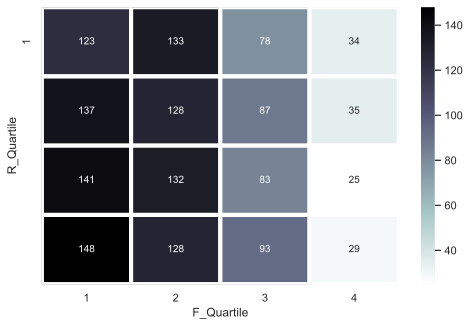

In [103]:
rfm_table = rfmSegmentation.pivot_table(
                        index='R_Quartile', 
                        columns='F_Quartile', 
                        values='monetary_value', 
                        aggfunc=np.median).applymap(int)
svm = sns.heatmap(rfm_table, cmap="bone_r", annot=True, fmt=".0f", 
                  linewidths=4.15, annot_kws={"size": 10},yticklabels=4)

### Possible questions and answers about the customers based on RFM segmentation

In [ ]:
#In which RFM Class there are more customers?
#Which RFM Class has the minimum number of customers?
#How many customers are there in the least-populated Class?
classes_count = rfmSegmentation.groupby('RFMClass', as_index=False)\
                .agg({'recency':'count'})\
                .rename(columns={'recency':'count'})\
                .sort_values('count', ascending=False)

classes_count

In [ ]:
#What is the lower border of transaction amount for users of Class 1 of Monetary Value Segment? 

M_1_lower = rfmSegmentation.query('M_Quartile == 1').groupby('customer_id').agg({'monetary_value':'sum'}).min()
M_1_lower

In [ ]:
#What is the lower border of number of purchases for the customers of Class 1 of Frequency Segment?
F_1_lower = rfmSegmentation.query('F_Quartile == 1').groupby('F_Quartile').agg({'frequency':'min'})
F_1_lower

In [ ]:
#What is the upper border of number of purchases for the customers of Class 4 of Frequency Segment?
F_4_upper = rfmSegmentation.query('F_Quartile == 4').groupby('F_Quartile').agg({'frequency':'max'})
F_4_upper

In [108]:
# We can group the customer into bigger groups and assign names to each such groups.
# Define the mapping of RFM scores to segment names

rfm_to_segment = {
    # Top Performers 
    111: "Top Performers", 112: "Top Performers", 113: "Top Performers", 114: "Top Performers",
    121: "Top Performers", 122: "Top Performers", 123: "Top Performers", 
    131: "Top Performers", 132: "Top Performers", 133: "Top Performers", 

    # Loyal Customers 
    134: "Loyal Customers", 124: "Loyal Customers",
    141: "Loyal Customers", 142: "Loyal Customers", 143: "Loyal Customers", 144: "Loyal Customers",
    211: "Loyal Customers", 212: "Loyal Customers", 213: "Loyal Customers", 214: "Loyal Customers",
    
    # Potential Loyalists 
    221: "Potential Loyalists", 222: "Potential Loyalists", 223: "Potential Loyalists", 224: "Potential Loyalists",
    231: "Potential Loyalists", 232: "Potential Loyalists", 233: "Potential Loyalists", 234: "Potential Loyalists",
    
    # Promising 
    241: "Promising", 242: "Promising", 243: "Promising", 244: "Promising",
    311: "Promising", 312: "Promising", 313: "Promising", 314: "Promising",
    
    # Needs Attention 
    321: "Needs Attention", 322: "Needs Attention", 323: "Needs Attention", 324: "Needs Attention",
    331: "Needs Attention", 332: "Needs Attention", 333: "Needs Attention", 334: "Needs Attention",
    
    # At Risk 
    341: "At Risk", 342: "At Risk", 343: "At Risk", 344: "At Risk",
    411: "At Risk", 412: "At Risk", 413: "At Risk", 414: "At Risk",
    
    # Can't Lose Them 
    421: "Can't Lose Them", 422: "Can't Lose Them", 423: "Can't Lose Them", 424: "Can't Lose Them",
    431: "Can't Lose Them", 432: "Can't Lose Them", 433: "Can't Lose Them", 434: "Can't Lose Them",
    
    # Nearly Lost Customers 
    441: "Lost Customers", 442: "Lost Customers", 443: "Lost Customers", 444: "Lost Customers"
}

rfm_to_segment

{111: 'Top Performers',
 112: 'Top Performers',
 113: 'Top Performers',
 114: 'Top Performers',
 121: 'Top Performers',
 122: 'Top Performers',
 123: 'Top Performers',
 131: 'Top Performers',
 132: 'Top Performers',
 133: 'Top Performers',
 134: 'Loyal Customers',
 124: 'Loyal Customers',
 141: 'Loyal Customers',
 142: 'Loyal Customers',
 143: 'Loyal Customers',
 144: 'Loyal Customers',
 211: 'Loyal Customers',
 212: 'Loyal Customers',
 213: 'Loyal Customers',
 214: 'Loyal Customers',
 221: 'Potential Loyalists',
 222: 'Potential Loyalists',
 223: 'Potential Loyalists',
 224: 'Potential Loyalists',
 231: 'Potential Loyalists',
 232: 'Potential Loyalists',
 233: 'Potential Loyalists',
 234: 'Potential Loyalists',
 241: 'Promising',
 242: 'Promising',
 243: 'Promising',
 244: 'Promising',
 311: 'Promising',
 312: 'Promising',
 313: 'Promising',
 314: 'Promising',
 321: 'Needs Attention',
 322: 'Needs Attention',
 323: 'Needs Attention',
 324: 'Needs Attention',
 331: 'Needs Attention',
 

#### Double-check if all our segments were included



In [109]:
len(rfm_to_segment)

64

In [110]:
# Define all possible RFM scores
all_rfm_scores = {i * 100 + j * 10 + k for i in range(1, 5) for j in range(1, 5) for k in range(1, 5)}
all_rfm_scores

{111,
 112,
 113,
 114,
 121,
 122,
 123,
 124,
 131,
 132,
 133,
 134,
 141,
 142,
 143,
 144,
 211,
 212,
 213,
 214,
 221,
 222,
 223,
 224,
 231,
 232,
 233,
 234,
 241,
 242,
 243,
 244,
 311,
 312,
 313,
 314,
 321,
 322,
 323,
 324,
 331,
 332,
 333,
 334,
 341,
 342,
 343,
 344,
 411,
 412,
 413,
 414,
 421,
 422,
 423,
 424,
 431,
 432,
 433,
 434,
 441,
 442,
 443,
 444}

In [111]:
len(all_rfm_scores)

64

In [112]:
# Existing RFM scores
existing_rfm_scores = set(rfm_to_segment.keys())
len(existing_rfm_scores)

64

In [113]:
# Check for excessive(or missing) scores
excessive_rfm_scores =  existing_rfm_scores - all_rfm_scores
excessive_rfm_scores

set()

In [114]:
#For correct mapping, check the types of columns in quesion
print(rfmSegmentation['RFMClass'].dtype)
print(type(list(rfm_to_segment.keys())[0]))

object
<class 'int'>


In [115]:
#For correct mapping, change data type of 'RFM Class' column into integers
rfmSegmentation['RFMClass'] = rfmSegmentation['RFMClass'].astype(int)

In [116]:
# Apply the segment mapping to the dataframe
rfmSegmentation['Segment'] = rfmSegmentation['RFMClass'].map(rfm_to_segment)

#### Resulting Segmentation Table

In [117]:

rfmSegmentation

,recency,frequency,monetary_value,R_Quartile,F_Quartile,M_Quartile,RFMClass,Segment
customer_id,,,,,,,,
0009655768c64bdeb2e877511632db8f,1,8,127.60,1,2,2,122,Top Performers
00116118485d4dfda04fdbaba9a87b5c,10,3,4.09,4,4,4,444,Lost Customers
0011e0d4e6b944f998e987f904e8c1e5,2,5,79.46,2,4,2,242,Promising
0020c2b971eb4e9188eac86d93036a77,0,8,196.86,1,2,1,121,Top Performers
0020ccbbb6d84e358d3414a3ff76cffd,2,12,154.05,2,1,1,211,Loyal Customers
...,...,...,...,...,...,...,...,...
fff3ba4757bd42088c044ca26d73817a,7,11,580.98,4,2,1,421,Can't Lose Them
fff7576017104bcc8677a8d63322b5e1,1,6,29.94,1,3,3,133,Top Performers
fff8957ea8b240a6b5e634b6ee8eafcf,6,5,12.15,4,4,4,444,Lost Customers


## OFFERS ANALYSIS

In [118]:
df_final.head()

,customer_id,event,time,offer_id,amount,offer_id_completed,reward,offer_type,difficulty,duration,channels,became_member_on,gender,age,income,offer_description,completed
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,5.0,bogo,5.0,7.0,"[web, email, mobile]",2017-05-09,F,75,100000.0,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,5.0,discount,20.0,10.0,"[web, email]",2017-08-04,NaN,118,NaN,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,2.0,discount,10.0,7.0,"[web, email, mobile]",2018-04-26,M,68,70000.0,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,2.0,discount,10.0,10.0,"[web, email, mobile, social]",2017-09-25,NaN,118,NaN,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,10.0,bogo,10.0,5.0,"[web, email, mobile, social]",2017-10-02,NaN,118,NaN,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",0


In [119]:
#No of offers by type completed
df_final.groupby('offer_type').agg({'completed':'sum'}).reset_index()

,offer_type,completed
0,bogo,15669
1,discount,17910
2,informational,0


In [120]:
#No of offers by type received
df_final.query('event=="offer received"').groupby('offer_type').agg({'completed':'count'}).reset_index()

,offer_type,completed
0,bogo,30499
1,discount,30543
2,informational,15235


In [121]:
#To analyze transactions attirbuted to offers, drop excessive columns
df_part1 = df_final.drop(columns=['completed', 'income', 'age', 'gender', 'became_member_on', 'channels', 'offer_id', 'duration', 'difficulty'])

In [122]:
offers_completed = df_part1.query('event=="offer completed"')

In [123]:
transactions_1 = df_part1.query('event=="transaction"')

In [124]:
merged_df_1 = pd.merge(offers_completed, transactions_1, on=['customer_id', 'time'], suffixes=('_completed', '_transaction'))

In [125]:
merged_df_1

,customer_id,event_completed,time,amount_completed,offer_id_completed_completed,reward_completed,offer_type_completed,offer_description_completed,event_transaction,amount_transaction,offer_id_completed_transaction,reward_transaction,offer_type_transaction,offer_description_transaction
0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,offer completed,0,NaN,2906b810c7d4411798c6938adc9daaa5,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",transaction,34.56,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
1,fe97aa22dd3e48c8b143116a8403dd52,offer completed,0,NaN,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",transaction,18.97,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
2,629fc02d56414d91bca360decdfa9288,offer completed,0,NaN,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0,bogo,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",transaction,33.90,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
3,676506bad68e4161b9bbaffeb039626b,offer completed,0,NaN,ae264e3637204a6fb9bb56bc8210ddfd,10.0,bogo,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",transaction,18.01,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
4,8f7dd3b2afe14c078eb4f6e6fe4ba97d,offer completed,0,NaN,4d5c57ea9a6940dd891ad53e9dbe8da0,10.0,bogo,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",transaction,19.11,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33574,0c027f5f34dd4b9eba0a25785c611273,offer completed,714,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,discount,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",transaction,11.44,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
33575,a6f84f4e976f44508c358cc9aba6d2b3,offer completed,714,NaN,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,discount,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",transaction,6.49,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
33576,b895c57e8cd047a8872ce02aa54759d6,offer completed,714,NaN,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",transaction,4.48,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."
33577,8431c16f8e1d440880db371a68f82dd0,offer completed,714,NaN,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",transaction,1.19,NaN,NaN,NaN,"Type: Unknown type, Difficulty: Unknown diffic..."


In [126]:
trasactions_on_offers = merged_df_1.drop(columns=['offer_description_transaction', 'offer_type_transaction', 'reward_transaction', 'offer_id_completed_transaction', 'amount_completed', 'event_completed', 'event_transaction'    ])

In [127]:
#Create dataset for further analysis of transactions and rewards associated with offers
df_offers_transactions = trasactions_on_offers\
                    .rename(columns={
                    'offer_id_completed_completed':'offer_id',
                    'reward_completed': 'reward',
                    'offer_type_completed':'type',
                    'offer_description_completed':'description',
                    'amount_transaction':'amount' })

In [128]:
df_offers_transactions

,customer_id,time,offer_id,reward,type,description,amount
0,9fa9ae8f57894cc9a3b8a9bbe0fc1b2f,0,2906b810c7d4411798c6938adc9daaa5,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",34.56
1,fe97aa22dd3e48c8b143116a8403dd52,0,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",18.97
2,629fc02d56414d91bca360decdfa9288,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,5.0,bogo,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",33.90
3,676506bad68e4161b9bbaffeb039626b,0,ae264e3637204a6fb9bb56bc8210ddfd,10.0,bogo,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",18.01
4,8f7dd3b2afe14c078eb4f6e6fe4ba97d,0,4d5c57ea9a6940dd891ad53e9dbe8da0,10.0,bogo,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",19.11
...,...,...,...,...,...,...,...
33574,0c027f5f34dd4b9eba0a25785c611273,714,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,discount,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",11.44
33575,a6f84f4e976f44508c358cc9aba6d2b3,714,2298d6c36e964ae4a3e7e9706d1fb8c2,3.0,discount,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",6.49
33576,b895c57e8cd047a8872ce02aa54759d6,714,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",4.48
33577,8431c16f8e1d440880db371a68f82dd0,714,fafdcd668e3743c1bb461111dcafc2a4,2.0,discount,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",1.19


In [129]:
amount_by_type = df_offers_transactions.groupby('type', as_index=False).agg({'amount':'sum'})

In [130]:
total_offer_amount = df_offers_transactions['amount'].sum()
total_offer_amount

687925.4400000001

In [131]:
amount_by_type['%_total_amount'] = amount_by_type['amount'] / total_offer_amount *1

In [132]:
#Gross revenue on transactions attributed of reward offers (by offer type)
amount_by_type

,type,amount,%_total_amount
0,bogo,328893.43,0.478095
1,discount,359032.01,0.521905


In [133]:
amount_by_offer = df_offers_transactions\
                .groupby('description', as_index=False)\
                .agg({'amount':'sum', 'reward':'sum'})

In [134]:
amount_by_offer['%_total_amount'] = amount_by_offer['amount'] / total_offer_amount * 100

In [135]:
total_reward_amount = df_offers_transactions['reward'].sum()

In [136]:
amount_by_offer['%_total_reward'] = amount_by_offer['reward'] / total_reward_amount * 100

In [137]:
#Find offers with largest transaction and reward amounts

amount_by_offer ['revenue_after_reward'] = amount_by_offer['amount'] - amount_by_offer['reward']

In [138]:
#Offers by amount of revenue after applying rewards
amount_by_offer.sort_values('revenue_after_reward', ascending=False)

,description,amount,reward,%_total_amount,%_total_reward,revenue_after_reward
4,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",97892.24,10634.0,14.230065,6.457529,87258.24
7,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",90552.42,15468.0,13.163115,9.392990,75084.42
5,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",82688.83,8034.0,12.020028,4.878671,74654.83
6,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",87898.52,17100.0,12.777332,10.384027,70798.52
2,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",83592.17,21480.0,12.151342,13.043795,62112.17
3,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",77911.04,21770.0,11.325506,13.219898,56141.04
1,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",88106.63,36880.0,12.807584,22.395492,51226.63
0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",79283.59,33310.0,11.525027,20.227598,45973.59


In [139]:
#Popularity of offers by number of transactions associated with them

transaction_nu_by_offers = df_offers_transactions\
                        .groupby('description', as_index=False)\
                        .agg({'amount':'count'})\
                        .rename(columns={'amount':'no_transactions'})

transaction_nu_by_offers

,description,no_transactions
0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3331
1,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3688
2,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4296
3,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4354
4,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",5317
5,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",4017
6,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",3420
7,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",5156


In [140]:
total_transactions = transaction_nu_by_offers['no_transactions'].sum()

In [141]:
transaction_nu_by_offers['%_total_transactions'] = transaction_nu_by_offers['no_transactions'] / total_transactions * 100

In [142]:
transaction_nu_by_offers

,description,no_transactions,%_total_transactions
0,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3331,9.919890
1,"Type: bogo, Difficulty: 10.0, Reward: 10.0, Du...",3688,10.983055
2,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4296,12.793710
3,"Type: bogo, Difficulty: 5.0, Reward: 5.0, Dura...",4354,12.966437
4,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",5317,15.834301
5,"Type: discount, Difficulty: 10.0, Reward: 2.0,...",4017,11.962834
6,"Type: discount, Difficulty: 20.0, Reward: 5.0,...",3420,10.184937
7,"Type: discount, Difficulty: 7.0, Reward: 3.0, ...",5156,15.354835
